[Home](../../README.md)

### Model Training - Polynomial Regression

Linear regression assumes the data has a linear pattern. If your data does not have a linear pattern you can consider a polynomial regression algorithm that provides a multi (poly) coefficient linear relationship between an independent variable and a dependent variable to predict the outcome of future events. We will now Train a Polynomial regression algorithm on the features you have engineered to see how closely we can predict the health outcomes for individuals.

#### Step 1

Load the required dependencies:

In [138]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
plt.style.use('../../style_Matplotlib_charts.mplstyle')
from sklearn.linear_model import LinearRegression
import pickle
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

#### Step 2

Store the data columns for Linear Regression.

In [139]:
# Create a data frame from the csv file
training_data = pd.read_csv('2.3.2.training_data.csv')

x_name = ['events_completed']
y_name = 'average'

X = training_data[x_name].values
y = training_data[y_name].values

x = X.flatten()

#### Step 3

To identify which feature provides the strongest predictive relationship with the target `average`, I plotted each feature in my dataset against the target and evaluated the patterns, noise levels, and overall usefulness for modelling. Most features showed weak or inconsistent relationships with the target, including years active, competitions entered, competitions per year, country, and continent. These variables displayed high variance and not many of them showing a clear trend, making them unsuitable as primary predictors.



#### Years active
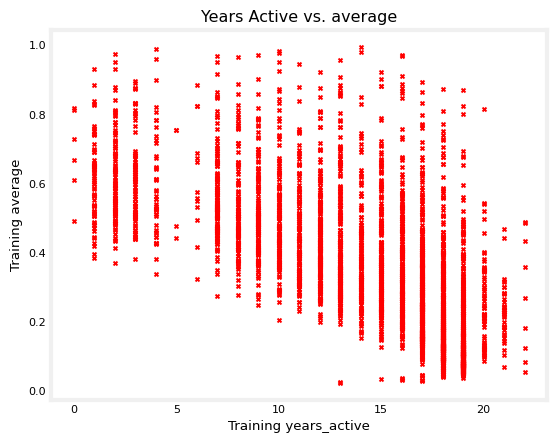

This plot shows the target 'average' plotted against the cubers years active. 


Observation: The plot shows a general downward trend: as years active increases, average solve time tends to decrease. However, this trend is very general, even with the obvious noise removed, it still does not show a promising trend.

Interperation: Experience ***barely*** correlates with target 'average', and more years of practice generally lead ot faster solves. 

Consideration for modelling: With reference to the former, although there is a slight downward trend suggesting more experienced users solve faster, the plot shows considerable variance at all levels of experience. Many cubers with similar years active have very different solve times, indicating that years_active alone cannot reliably predict performance. This inconsistency reduces the model’s predictive strength.

#### Competitions Entered
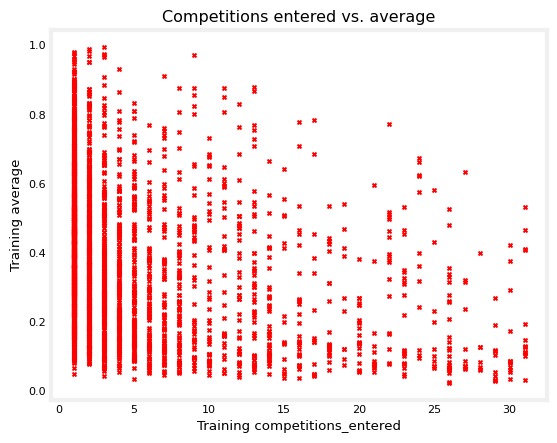

This plot shows the target 'average' plotted against the cubers competitions entered. 

Observations: The plot shows a significatn downwards trend with substantial scatter. There are also many users with few competitions that have both high and low solve times.

Interpertation: This form of competiion experience *** somewhat *** correlates with the target 'average', and may help omprove solve time

Consideration for modelling: The graph shows only a somewhat downwards trend, with cubers who have entered fewer competitions spanning the full range of solve times. The large scatter suggests that competition participation alone does not strongly determine performance, so including this feature does little to improve model accuracy.

#### Competitions Per Year
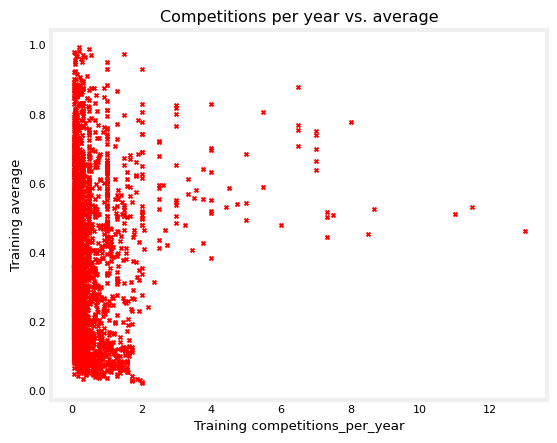

This plot shows the target 'average' plotted against the cubers competitions per year. 

Observations: Most cubers are clustering at a low competitions rate per year - only a few compete frequently. The solve times are also highly scattered.

Interpertation: This form of competiion experience *** barely *** correlates with the target 'average'. Frequent competitions does not clearly predict solve time for most cubers. This is likely due to the sparse data at the level of high competitions per year.

Consideration for modelling: Most users cluster at low competition frequency, and solve times remain highly variable across all values. The sparse distribution at higher competition rates means the feature provides very little predictive signal, making it a weak contributor to the model.

#### Country
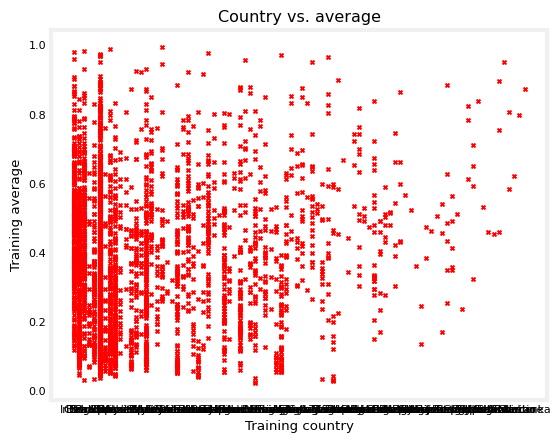

This plot shows the target 'average' plotted against the cubers country. 

Observations: Data points are widely scattered across countries. No obvious trend shows that users from a specific country consistently solve faster.

Interpretation: This form of competiion experience *** does not *** correlates with the target 'average'. Solve time does not appear to strongly depend on the user’s country. Differences may be potentially cultural or resource-based, such as specific rural areas, but no countries are linearly predictive.

Consideration for modelling: Solve times are widely scattered across different countries with no clear trend. This indicates that nationality does not strongly influence performance, and the model gains minimal predictive power from this feature.

#### Continent
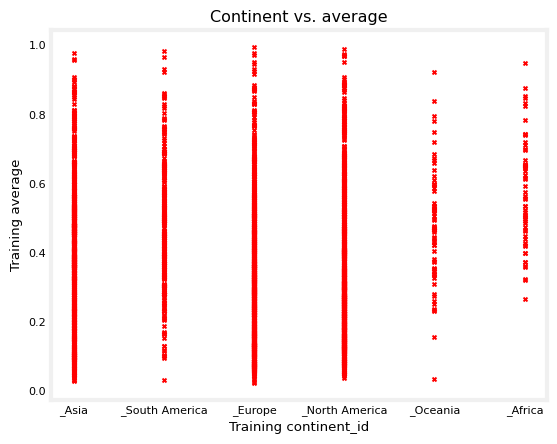

This plot shows the target 'average' plotted against the cubers continent. 

Observations: Users are grouped by continent, but scatter shows similar distributions across continents. No clear predictive trend.

Interpretation: This form of competiion experience *** does not *** correlates with the target 'average'. Regional grouping has minimal direct influence on solve time.

Consideration for modeling: Cubers grouped by continent also show overlapping solve times with no distinct patterns. The lack of variation between continents implies this feature also adds a negligible predictive value to this model.

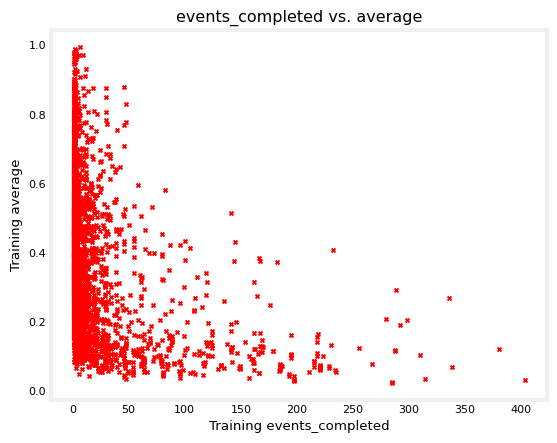

In [140]:
if(len(x_name) == 1):
    plt.scatter(x, y, marker='x', c='r', s=1)
    plt.title("events_completed vs. average")
    plt.ylabel(f'Training {y_name}')
    plt.xlabel(f'Training {x_name[0]}')
else:
    fig,ax=plt.subplots(1,len(x_name),figsize=(12,3))
    for i in range(len(ax)):
        ax[i].scatter(x[:,i],y, label = 'target')
        ax[i].set_xlabel(x_name[i])
    ax[0].set_ylabel("average"); ax[0].legend();
    fig.suptitle("events_completed vs. average")
plt.show()

Amongst all the features analysed, events_completed showed the strongest and most interpretable relationship with the target variable average, as as the number of events completed increases, the average score consistently rises, with a clear diminishing‑returns pattern. This structure is ideal for a non‑linear model, as the pattern very clearly be fitted with an exponential decay curve to produce a clean model. Because it is both highly predictive and easy to interpret, I selected `events_completed` as the primary feature for the machine‑learning model.

Other features, such as continent, showed no clear separation between groups and therefore offered little predictive value. Additionally, competitions_entered was strongly related to events_completed, making it somewhat redundant as a feature. However, events_completed was clearly superior in terms of modelability.  I also considered feature engineering events_completed with competitions_entered due to them being my two best features, however, I quickly realsied that the amount of events one comlpeted, is a subset of the total competitions they enter (as they go to a competition to compete in events), so I just stuck with evetns_completed to be my final model

Because events_completed provides both strong predictive power and a clear mathematical relationship with the target variable, it was selected as the primary feature for the final machine learning model.

##### Removing Noise and Outliers 

Although the plot shows a clear overall clear relationship between events_completed and average, there is also a large amount of noise, particularly among competitors with very low event counts of events completed. These cubers tend to have highly inconsistent averages because they have not competed enough times for their performance to stabilise.

To reduce the impact of this noise, I decided to smooth the data by grouping competitors into bins based on events_completed and calculating the mean average for each bin. This allows the overall trend to become clearer while still preserving the underlying structure of the data.

In [141]:
# first, a temporary dataframe is created to store the events_complete values and the average values
df_t = pd.DataFrame({'x' : x, 'y': y})

# next, pd.cut divides events completed values into equally spaced bins. each bin will then represent a small range of event_completed counts
df_t['bin'] = pd.cut(df_t['x'], bins=50)
# The data is then grouped by these bins and the mean average for each bin is calculated which reduces the influence of outliers and highlights the trend in the data more clearly.
binned = df_t.groupby("bin", observed=True)["y"].mean().reset_index()
# Finally the midpoint of each bin is calculated so the averaged values can be plotted smoothly on the graph
binned["x_mid"] = binned["bin"].apply(lambda b: b.mid)

binned = binned.dropna()

x_binned = binned['x_mid'].values.astype(float)
y_binned = binned['y'].values.astype(float)

After binning the data, the relationship between events_completed and average becomes much clearer. The graph shows that as the number of events completed increases, the average score generally improves. However, the rate of improvement gradually slows over time.

This pattern reflects a diminishing returns/exponential decay relationship, where competitors improve rapidly when they first begin competing, but their improvement slows as they gain more experience.

To model the diminished returns relationship, I used an exponential decay function. This type of function is appropriate because improvement happens rapidly at first, before gradually slowing as experience increases.

A exponential decay function is defined as y = a⋅e^−bx+c

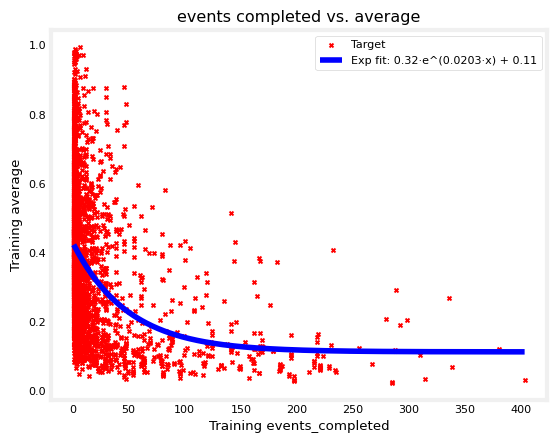

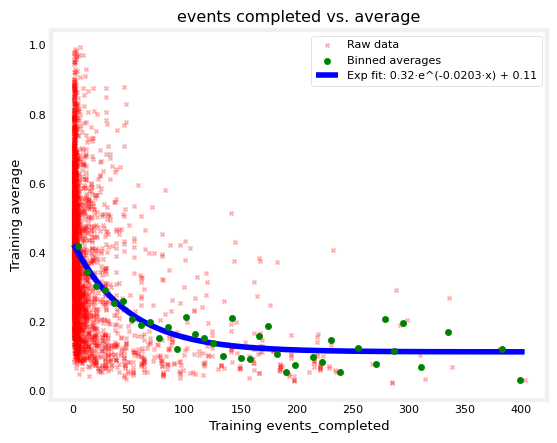

In [142]:
def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c

params, covariance = curve_fit(exp_func, x_binned, y_binned, p0=[1, 0.01, 0.1], maxfev=10000)
a, b, c, = params

x_sorted = np.linspace(x.min(), x.max(), 300)
y_pred = exp_func(x_sorted, a, b, c)
y_pred_points = exp_func(x, a, b, c)

plt.scatter(x, y, marker='x', c='r', s=1, label='Target')
plt.plot(x_sorted, y_pred, color='blue', label=f'Exp fit: {a:.2f}·e^({b:.4f}·x) + {c:.2f}')
plt.title("events completed vs. average")
plt.ylabel(f'Training {y_name}')
plt.xlabel(f'Training {x_name[0]}')
plt.legend()
plt.show()


plt.scatter(x, y, marker='x', c='r', s=1, label='Raw data', alpha=0.3)
plt.scatter(x_binned, y_binned, c='green', s=20, zorder=5, label='Binned averages')
plt.plot(x_sorted, y_pred, color='blue', label=f'Exp fit: {a:.2f}·e^(-{b:.4f}·x) + {c:.2f}')
plt.title("events completed vs. average")
plt.ylabel(f'Training {y_name}')
plt.xlabel(f'Training {x_name[0]}')
plt.legend()
plt.show()

The models visualised by plotting the 
- *raw training data as red scatter points*, 
- *the binned averages as the green points on the second graph*, 
- *and the exponential fitte curve as a blue line*

This visualisation, especially the green binned data points, helps confirm that the exponential model captures the overall trend of the data while smoothing out noise and outliers.  

The resulting curve shows the expected learning curve behavioour, where the competitors improve quickly in there earlier events but gradually drops once they hit their performance stabilises. 

##### Model predictions

Once the parameters for the exponential function were found, I used the model to generate predicted values for the dataset.

the code below applies the fitted exponential function to the original events_completed values, which produces predicted average scores based on the model’s now learned relationship/

These predicted values represent what the model expects the average performance to be for competitors with a given number of completed events, which allows for the predictions to be compared with the actual values to assess the accuracy and reliability of the model prior to the Model Evaluation stage.

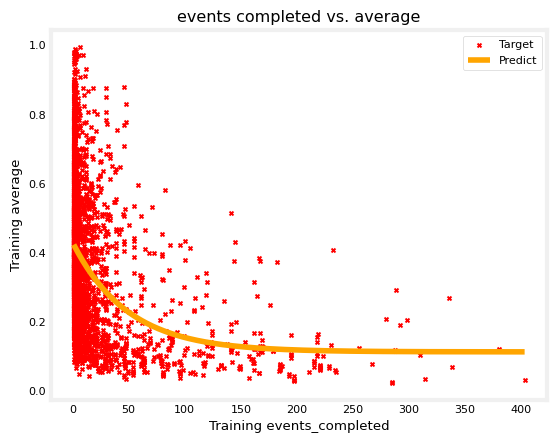

In [143]:
y_pred_points = exp_func(x, a, b, c)

if len(x_name) == 1:
    plt.scatter(x, y, marker="x", c="r", s=1, label="Target")
    plt.plot(x_sorted, exp_func(x_sorted, a, b, c), c="orange", label="Predict")  # use line instead
    plt.title("events completed vs. average")
    plt.ylabel(f"Training {y_name}")
    plt.xlabel(f"Training {x_name[0]}")
    plt.legend()
plt.show()

As you can see, the resulting prediction curve closely follows the overall trend of the data. It shows that competitors improve rapidly when they first begin competing, but their improvement slows as they gain more experience and their performance stabilises.

This behaviour reflects a typical learning curve, where early practice produces large improvements while later gains become smaller over time.

Because the model successfully captures this diminishing-returns/exponential decay pattern, the function provides a suitable representation of the relationship between events_completed and average performance.

In [144]:
# save the exp model to disk
poly_filename = 'my_saved_poly_v3.pkl'
model_data = {'a': a, 'b': b, 'c': c}
pickle.dump(model_data, open('../2.4.Model_Testing_and_Validation/' + poly_filename, 'wb'))

model_filename = "my_saved_model_v3.sav"
model_data = {"a": float(a), "b": float(b), "c": float(c)}

out_path = Path("../2.4.Model_Testing_and_Validation") / model_filename
with open(out_path, "wb") as f:
    pickle.dump(model_data, f)

print(f"Model saved: a={a:.4f}, b={b:.4f}, c={c:.4f}")

Model saved: a=0.3163, b=0.0203, c=0.1128
